# Session 00: Why This Course Exists

**Companion notebook to the Session 00 lecture notes.**

Run every cell in order.
Do not skip the plots. The plots are where the lesson lives.

## 1.1 The Problem

A projectile is launched from level ground at angle $\theta$ with an initial speed
$v$. The only force acting on it is gravity; we ignore air
resistance. We have measured the horizontal range $R$ at several angles, with noise. Our task: predict the range at some new angles.

**We do not know the formula.** We have only the measurements.

---

# Part 1

> **This is a performance!**

In [2]:
import numpy as np

np.random.seed(0)

X_train = np.load('X_train.npy')
X_test = np.load('X_test.npy')

y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')

print(f"X_training data shape: {X_train.shape}")
print(f"X_test data shape: {X_test.shape}")
print(f"y_train data shape: {y_train.shape}")
print(f"y_test data shape: {y_test.shape}")

X_training data shape: (30, 1)
X_test data shape: (200, 1)
y_train data shape: (30,)
y_test data shape: (200,)


In [3]:
train_data = np.concatenate([X_train, y_train.reshape(-1, 1)], axis=1)
print('train_data: \n', train_data.shape)
print('train_data: \n', train_data)

train_data: 
 (30, 2)
train_data: 
 [[ 5.          7.11817483]
 [ 6.03448276  8.48591032]
 [ 7.06896552 10.1516389 ]
 [ 8.10344828 11.41196717]
 [ 9.13793103 12.62594335]
 [10.17241379 14.28459836]
 [11.20689655 15.93831259]
 [12.24137931 17.18195913]
 [13.27586207 18.01540497]
 [14.31034483 19.1518259 ]
 [15.34482759 20.62393151]
 [16.37931034 22.07563969]
 [17.4137931  22.58929445]
 [18.44827586 24.41436642]
 [19.48275862 25.26751362]
 [20.51724138 26.54945834]
 [21.55172414 27.69881064]
 [22.5862069  28.82382123]
 [23.62068966 30.06111889]
 [24.65517241 31.23026924]
 [25.68965517 31.81852979]
 [26.72413793 33.16506862]
 [27.75862069 33.41090413]
 [28.79310345 34.52742687]
 [29.82758621 35.45964654]
 [30.86206897 35.93756158]
 [31.89655172 36.36024157]
 [32.93103448 36.93300955]
 [33.96551724 37.64993111]
 [35.         38.38176173]]


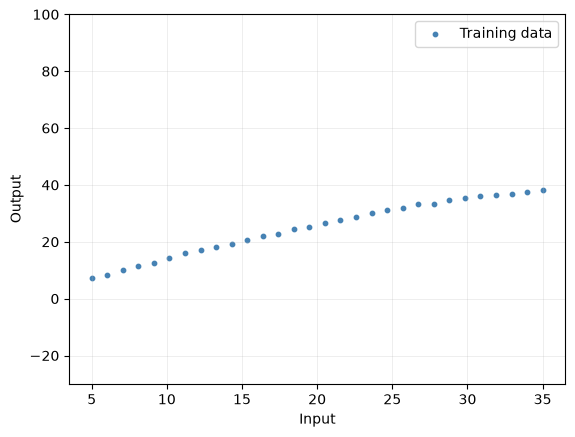

In [4]:
import matplotlib.pylab as plt

%matplotlib inline

plt.figure()
plt.scatter(X_train, y_train, color='steelblue', s=10, label="Training data")

plt.ylim(-30,100)
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 1.2 Attempt 1 — Linear Regression

Start simple. Fit a line.

In [5]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X_train, y_train)

Y_pred = lin.predict(X_test)
print(Y_pred[:10])
print(y_test[:10])


[14.33366406 14.51970583 14.70574761 14.89178939 15.07783117 15.26387295
 15.44991473 15.63595651 15.82199828 16.00804006]
[13.94577547 14.18074465 14.41517934 14.6490707  14.88240991 15.11518819
 15.34739675 15.57902684 15.81006974 16.04051673]


In [6]:
train_r2 = lin.score(X_train,y_train)
test_r2 = lin.score(X_test,y_test)

print(f"linear regression train r2: {train_r2:.4f}")
print(f"linear regression test r2: {test_r2:.4f}")

linear regression train r2: 0.9863
linear regression test r2: 0.8027


Train $R^2$ is nearly perfect. Test $R^2$ is not.

**So let's add complexity!**

## 1.3 Attempt 2 — Tree-base Regression

In [7]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dt = DecisionTreeRegressor(random_state=0)
rf = RandomForestRegressor(n_estimators=100, random_state=0)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

dt_train_r2 = dt.score(X_train, y_train)
rf_train_r2 = rf.score(X_train, y_train)

print(f"Decision tree train r2: {dt_train_r2:.4f}")
print(f"Random forest train r2: {rf_train_r2:.4f}")
print()

dt_test_r2 = dt.score(X_test, y_test)
rf_test_r2 = rf.score(X_test, y_test)
print(f"Decision tree test r2: {dt_test_r2:.4f}")
print(f"Random forest test r2: {rf_test_r2:.4f}")


Decision tree train r2: 1.0000
Random forest train r2: 0.9989

Decision tree test r2: 0.9853
Random forest test r2: 0.9812


## 1.4 Attempt 3 — Polynomial Features

Give the model more flexibility. Fit polynomials of increasing degree.

In [8]:
from sklearn.preprocessing  import PolynomialFeatures
from sklearn.pipeline import make_pipeline

result = {}
for degree in {1, 2, 3, 5, 10, 15}:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    result[degree] = model
    print(f"degree= {degree}, train r2 = {train_r2}, test_r2 = {test_r2}")

degree= 1, train r2 = 0.9863362529765424, test_r2 = 0.802723754948023
degree= 2, train r2 = 0.9990620391489267, test_r2 = 0.9920696065211265
degree= 3, train r2 = 0.9994211708335768, test_r2 = 0.997515068189794
degree= 5, train r2 = 0.9934237929074318, test_r2 = -1.368732620622052
degree= 10, train r2 = 0.8643935538945968, test_r2 = -2740.5137206776426
degree= 15, train r2 = 0.7020873095640467, test_r2 = -185222.2744849077


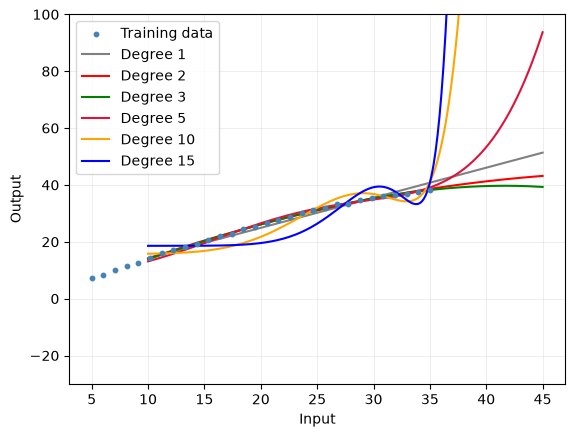

In [9]:
plt.figure()
plt.scatter(X_train, y_train, color='steelblue', s=10, label="Training data", zorder=3)

color = {1: 'gray', 2: 'red', 3: 'green', 5: 'crimson', 10: 'orange', 15: 'blue'}
for degree, model in result.items():
    y_pred = model.predict(X_test)
    plt.plot(X_test, y_pred, color=color[degree], linewidth=1.5, label=f'Degree {degree}')

plt.ylim(-30,100)
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 1.5 Attempt 4 — Regularization

Control the wildness of the polynomial with a ridge penalty.

In [10]:
from sklearn.linear_model import Ridge

for alpha in [0.01, 1.0, 100.0]:
    model = make_pipeline(PolynomialFeatures(5), Ridge(alpha=alpha))
    model.fit(X_train, y_train)
    test = model.score(X_test, y_test)
    print(f"alpha={alpha:7.2f}  test R^2={test:.3f}")

alpha=   0.01  test R^2=0.960
alpha=   1.00  test R^2=0.829
alpha= 100.00  test R^2=0.969


C:\Users\mmnas\Machine Learning Education\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5041043932696953e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\mmnas\Machine Learning Education\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5041043932696952e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Better, but still below degree-3's score.

**Let's try every model!**

## 1.6 Attempt 5 — Throw Every Model at the Problem

When in doubt, run a model zoo.

In [11]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

models = {
    "Grad Boosting": GradientBoostingRegressor(random_state=0),
    "SVR":           SVR(),
    "k-NN":          KNeighborsRegressor(),
    "MLP":           MLPRegressor(hidden_layer_sizes=(64, 64),
                                  max_iter=5000, random_state=0),
}

print(f"{'Model':12s}  {'R^2':>8s}")
print("-" * 26)
for name, m in models.items():
    m.fit(X_train, y_train)
    r2 = m.score(X_test, y_test)
    print(f"{name:15s}  {r2:0.4f}")

Model              R^2
--------------------------
Grad Boosting    0.9853
SVR              0.4591
k-NN             0.9598
MLP              0.3939


## 1.7 Attempt 6 — The Victory Lap

Poly_3: classic and simple. Let us use it.

In [12]:
poly_3 = make_pipeline(PolynomialFeatures(3), LinearRegression())
poly_3.fit(X_train, y_train)
y_pred_poly_3 = poly_3.predict(X_test)

print(f"poly_3 test R^2: {poly_3.score(X_test, y_test):.3f}")

poly_3 test R^2: 0.998


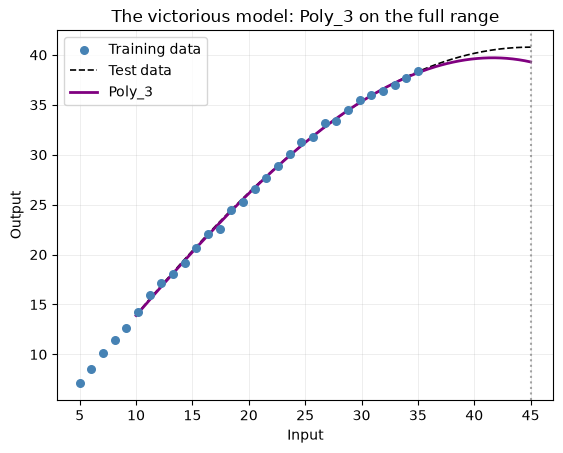

In [13]:
plt.figure()
plt.scatter(X_train, y_train, color='steelblue', s=30,
            label='Training data', zorder=3)
plt.plot(X_test, y_test, 'k--', linewidth=1.2,
         label='Test data')
plt.plot(X_test, y_pred_poly_3, color='purple', linewidth=2,
         label='Poly_3')
plt.axvline(45, color='gray', linestyle=':', alpha=0.7)
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('The victorious model: Poly_3 on the full range')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Test $R^2 = 0.998$. It is very high. The demo succeeded. Now we have a working model!

---

# Part 2 — The Debrief

> **Now we step out of the role.** What did we actually do?

## 2.1 What Did We Just Do?

We produced a working model, and we understand nothing about it.

We chose a model because of a number. We chose hyperparameters because of a number. We congratulated ourselves on a number. We never asked what the model assumes, what the phenomenon's shape is, or whether the two match.

Let us look at the failures one by one.

## 2.2 Failure 1 — We Never Asked What the Shape Was

The true range is $R(\theta) = \frac{v^2}{g}\sin(2\theta+\phi)$. It is a sine wave.
It rises from $0$ at $2\theta+\phi = 0^\circ$, peaks at $45^\circ$, and falls back to
$0$ at $90^\circ$. This is the **shape** of the phenomenon. It is fixed by
physics and nothing else.

We never wrote this down. But here is the deeper point: the shape cannot be
seen in the data. From measurements alone in $[5, 35]$, any smooth function
that fits the window is equally consistent. The shape comes from the physics
of projectile motion, not from the measurements. Without the physics, there is
nothing to constrain the extrapolation.

Let us write the shape down now — but only to see how badly every model we
tried gets it wrong outside the training window.

## 2.3 Failure 2 — We Celebrated a Correct Answer for the Wrong Reason

The Poly_3 gave test $R^2 = 0.998$. On the surface, that looks like success. But look again at the prediction curve. Its prediction at 40 degrees happens to be roughly in the right neighborhood, not because the model understands the physics.

Let us push further. Let us test the model at 80 degrees — a physically valid launch angle with a well-known range.

In [14]:
v = 20.0
g = 9.81
def true_range(theta_deg):
    theta = np.deg2rad(theta_deg)
    return v**2 * np.sin(2 * theta) / g

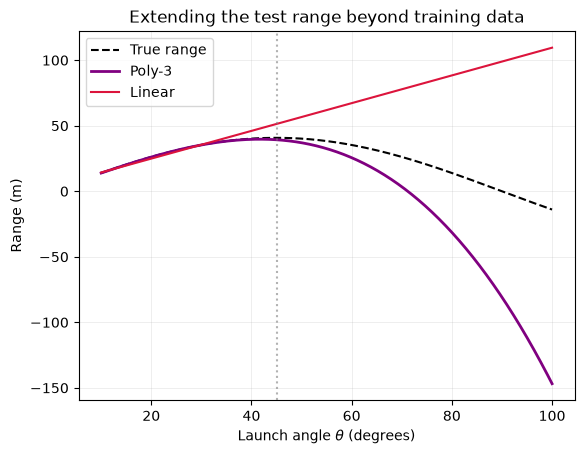

True range at 60 deg: 35.31 m
Poly-3 prediction at 60 deg: 25.61 m
Linear prediction at 60 deg: 67.22 m

True range at 120 deg: -35.31 m
Poly-3 prediction at 120 deg: -336.18 m
Linear prediction at 120 deg: 130.69 m


In [22]:
theta_extended = np.linspace(10, 100, 200)
y_extended = true_range(theta_extended)

fig, ax = plt.subplots()
ax.plot(theta_extended, y_extended, 'k--', linewidth=1.5,
        label='True range')
ax.plot(theta_extended, poly_3.predict(theta_extended.reshape(-1, 1)),
        color='purple', linewidth=2, label='Poly-3')
ax.plot(theta_extended, lin.predict(theta_extended.reshape(-1, 1)),
        color='crimson', linewidth=1.5, label='Linear')
ax.axvline(45, color='gray', linestyle=':', alpha=0.6)
ax.set_xlabel(r'Launch angle $\theta$ (degrees)')
ax.set_ylabel('Range (m)')
ax.set_title('Extending the test range beyond training data')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"True range at 60 deg: {true_range(60):.2f} m")
print(f"Poly-3 prediction at 60 deg: {poly_3.predict([[60]])[0]:.2f} m")
print(f"Linear prediction at 60 deg: {lin.predict([[60]])[0]:.2f} m")
print()
print(f"True range at 120 deg: {true_range(120):.2f} m")
print(f"Poly-3 prediction at 120 deg: {poly_3.predict([[120]])[0]:.2f} m")
print(f"Linear prediction at 120 deg: {lin.predict([[120]])[0]:.2f} m")

The poly_3 predicts a value that has nothing to do with the truth. Its confident test $R^2$ of 0.998 was a coincidence of the specific range we happened to test on. Push the range slightly, and the model falls apart.

## 2.4 Failure 3 — Model Choice as a Substitute for Understanding

When the first model failed, we did not ask *why*. We added complexity. Then we did not ask why. We added regularization. When regularization was not enough, we did not ask why. We threw models at the problem until one stuck.

This is not engineering. This is gambling with extra steps. The result is a model whose behavior we cannot predict, cannot explain, and cannot defend when it fails in production.

---

# Part 3 — The Right Way

> Same problem. Same data. Same tools. Different starting point.

## 3.1 Write Down the Shape First

Before choosing a model, ask what shape the phenomenon has. In the projectile
problem, we can derive it.

A projectile launched from level ground with speed $v$ at angle $\theta$
experiences constant downward acceleration $g$. Its position at time $t$ is

$$x(t) = v\cos\theta \cdot t, \qquad y(t) = v\sin\theta \cdot t - \tfrac{1}{2} g t^2.$$

The projectile lands when $y(t) = 0$ and $t > 0$, which gives the flight time

$$t^* = \frac{2 v \sin\theta}{g}.$$

Substituting into the horizontal equation:

$$R(\theta) = x(t^*) = v\cos\theta \cdot \frac{2 v \sin\theta}{g}
= \frac{v^2}{g}\sin(2\theta).$$

The shape is a sinusoid of period $180^\circ$ in $\theta$. This is not an
assumption — it is a consequence of the physics.

**Why this matters.** If we had only the data, we could not know this. Every
function that agrees with the measurements in the training window is consistent
with the data. The physics is what breaks the tie. Without it, extrapolation is
guesswork.

The derivation tells us the shape class:
- The function is periodic in $\theta$ with period $180^\circ$.
- It is symmetric about $\theta = 45^\circ$ within each period.
- It vanishes at $\theta = 0^\circ$ and $\theta = 90^\circ$.

These are strong constraints. They should be built into the hypothesis class.

## 3.2 Choose a Hypothesis Class That Matches

If the shape is a sinusoid of period $180^\circ$, our hypothesis class should
be sinusoids of period $180^\circ$. The general form of such a sinusoid is

$$f(\theta) = A \sin(2\theta + \phi)$$

for some amplitude $A$ and phase $\phi$. Using the angle-addition formula,

$$A\sin(2\theta + \phi)
= \underbrace{A\cos\phi}_{a}\sin(2\theta) + \underbrace{A\sin\phi}_{b}\cos(2\theta).$$

So the hypothesis class

$$f(\theta) = a\sin(2\theta) + b\cos(2\theta)$$

spans every sinusoid of period $180^\circ$, with arbitrary amplitude and phase.

**Why not just $\sin(2\theta)$?** If we used only the first term, we would be
assuming the phase is zero. The physics derivation gives a phase of zero, but
in real engineering problems phase offsets arise from calibration, launch-point
offset, or measurement timing. Using both $\sin(2\theta)$ and $\cos(2\theta)$ is
the minimal honest basis: it spans all sinusoids of the right period, and lets
the data choose the phase. If the fit returns $b = 0$, that is a *result*, not
an assumption.

This is still a *linear* model in the parameters $(a, b)$. It is just linear
in a better feature space. The features are $\sin(2\theta)$ and $\cos(2\theta)$,
not $\theta$ and $\theta^2$.

Watch what happens.

In [18]:
def sin_cos_features(theta_deg):
    theta = np.deg2rad(theta_deg)
    return np.c_[np.sin(2 * theta), np.cos(2 * theta)]

Phi_train = sin_cos_features(X_train)
Phi_test  = sin_cos_features(X_test)

model = LinearRegression().fit(Phi_train, y_train)
y_pred = model.predict(Phi_test)

print(f"Train R^2: {model.score(Phi_train, y_train):.4f}")
print(f"Test  R^2: {model.score(Phi_test, y_test):.4f}")
print(f"Prediction at 60 deg: {model.predict(sin_cos_features([60]))[0]:.2f} m")
print(f"True value at 60 deg: {true_range(60):.4f} m")
print(f"Prediction at 120 deg: {model.predict(sin_cos_features([120]))[0]:.2f} m")
print(f"True value at 120 deg: {true_range(120):.4f} m")

Train R^2: 0.9994
Test  R^2: 0.9999
Prediction at 60 deg: 36.05 m
True value at 60 deg: 35.3119 m
Prediction at 120 deg: -33.39 m
True value at 120 deg: -35.3119 m


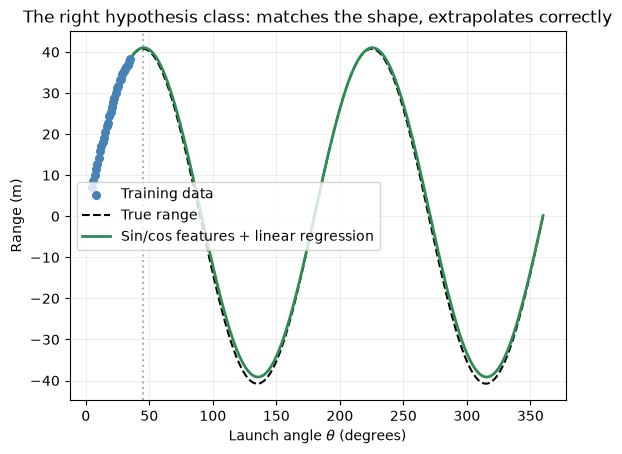

In [21]:
theta_far = np.linspace(10, 360, 200)
y_far = true_range(theta_far)
y_pred_far = model.predict(sin_cos_features(theta_far))

plt.figure()
plt.scatter(X_train, y_train, color='steelblue', s=30,
            label='Training data', zorder=3)
plt.plot(theta_far, y_far, 'k--', linewidth=1.5,
         label='True range')
plt.plot(theta_far, y_pred_far, color='seagreen', linewidth=2,
         label='Sin/cos features + linear regression')
# plt.plot(theta_far, poly_3.predict(theta_far.reshape(-1, 1)), color='purple', linewidth=2,
#          label='Poly_3')

plt.axvline(45, color='gray', linestyle=':', alpha=0.6)
plt.xlabel(r'Launch angle $\theta$ (degrees)')
plt.ylabel('Range (m)')
plt.title('The right hypothesis class: matches the shape, extrapolates correctly')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3.3 What This Demonstrates

Look at the two numbers:

- The model trained on $\sin(2\theta)$ and $\cos(2\theta)$ has essentially perfect test $R^2$ across the *entire* range, including points far outside the training window.
- It predicts 60 degrees correctly. It predicts 120 degrees correctly. It would predict 200 degrees correctly, and 350 degrees correctly, because it has captured the actual shape of the phenomenon.

We did not need a bigger model. We did not need more data. We did not need regularization, ensemble methods, or hyperparameter tuning.

**We needed to know the shape.**

Same data. Same tools. Different starting point.
##### This is the difference between machine learning as API usage and machine learning as engineering.

---

# Summary

1. The conventional demo produced a working model with no understanding. It would be impossible to defend in a design review or a post-mortem.
2. The failure was not algorithmic. It was representational. Every model we tried assumed a shape that did not match the phenomenon.
3. The fix was to write down the shape first, then choose a hypothesis class that respects it. This required knowing the physics. It did not require any advanced mathematics.
4. The rest of this course is the systematic study of how to do step 3 for problems where the shape is not written on the blackboard.

**The question we leave with:** *How do we know which representation is right for a problem when the physics does not hand it to us?*

This is what Session 1 begins to answer, with a broken toy: a cantilever beam whose raw coordinates are misleading.